# Importing libraries

In [73]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import shutil
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

# Loading data

In [ ]:
def load_disease_list(file_path):
    disease_list = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                _, name = line.split(' ', 1)
                disease_list.append(name)
    return disease_list

In [ ]:
def load_image_filenames(txt_path):
    filenames = []

    with open(txt_path, 'r') as file:
        for line in file:
            parts = line.strip().split()

            if len(parts) < 2:
                continue

            full_path = parts[1]
            filename = full_path.split('/')[-1]
            filenames.append(filename)
            
    return filenames

In [ ]:
def map_images_to_lesions(mapping_txt_path, lesions):
    image_lesion_labels = []

    with open(mapping_txt_path, 'r') as file:

        for line in file:
            parts = line.strip().split()

            if len(parts) != 2:
                continue

            image_idx, lesion_idx = parts
            image_idx = int(image_idx)
            lesion_idx = int(lesion_idx)

            lesion_name = lesions[lesion_idx - 1]

            image_lesion_labels.append(lesion_name)

    return image_lesion_labels

In [ ]:
lesions = load_disease_list('../datasets/sd-198/classes.txt')

images = load_image_filenames('../datasets/sd-198/images.txt')

correspondent = map_images_to_lesions('../datasets/sd-198/image_class_labels.txt', lesions)

print(len(lesions))
print(len(images))
print(len(correspondent))

data = {
    'img_id': images,
    'label': correspondent
}

df = pd.DataFrame(data)

print(df.head())

198
6584
6584
          img_id                   label
0   009514HB.jpg  Acne_Keloidalis_Nuchae
1  009514HB1.jpg  Acne_Keloidalis_Nuchae
2   009881HB.jpg  Acne_Keloidalis_Nuchae
3   009888HB.jpg  Acne_Keloidalis_Nuchae
4   009889HB.jpg  Acne_Keloidalis_Nuchae


In [78]:
print("First 5 lesions:", lesions[:5])
print("First 5 images:", images[:5])
print("First 5 correspondents:", correspondent[:5])

First 5 lesions: ['Acne_Keloidalis_Nuchae', 'Acne_Vulgaris', 'Acrokeratosis_Verruciformis', 'Actinic_solar_Damage(Actinic_Cheilitis)', 'Actinic_solar_Damage(Actinic_Keratosis)']
First 5 images: ['009514HB.jpg', '009514HB1.jpg', '009881HB.jpg', '009888HB.jpg', '009889HB.jpg']
First 5 correspondents: ['Acne_Keloidalis_Nuchae', 'Acne_Keloidalis_Nuchae', 'Acne_Keloidalis_Nuchae', 'Acne_Keloidalis_Nuchae', 'Acne_Keloidalis_Nuchae']


# Merge image folders

In [ ]:
def move_images_to_base(base_dir):
    for root, _, files in os.walk(base_dir, topdown=False):

        if root == base_dir:
            continue

        for file in files:
            
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.tiff')):
                src_path = os.path.join(root, file)
                dest_path = os.path.join(base_dir, file)

                if os.path.exists(dest_path):
                    print(f"Skipped (already exists): {file}")
                    continue

                shutil.move(src_path, dest_path)
                print(f"Moved: {src_path} -> {dest_path}")

# Label mapping

In [81]:
malignant_classes = [
    "Basal_Cell_Carcinoma",
    "Bowen's_Disease",
    "Malignant_Melanoma",
    "Lentigo_Maligna_Melanoma",
    "Cutaneous_T-Cell_Lymphoma",
    "Metastatic_Carcinoma"
]

df['benign_malignant'] = df['label'].apply(
    lambda x: 'malignant' if x in malignant_classes else 'benign'
)

df = df.drop(columns=['label'])

print(df.head())

          img_id benign_malignant
0   009514HB.jpg           benign
1  009514HB1.jpg           benign
2   009881HB.jpg           benign
3   009888HB.jpg           benign
4   009889HB.jpg           benign


# Viewing the label distribution

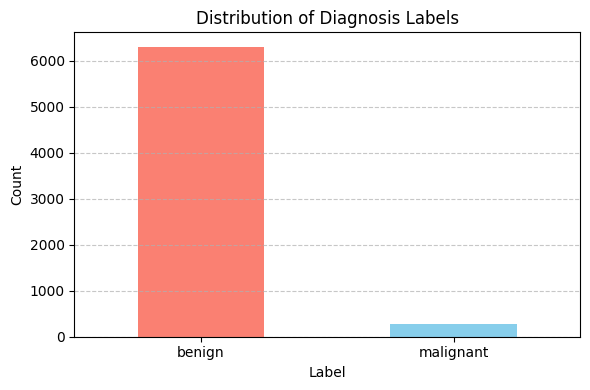


Category distribution:
benign_malignant
benign       6308
malignant     276
Name: count, dtype: int64


In [ ]:
label_counts = df['benign_malignant'].value_counts()

plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['salmon', 'skyblue'])

plt.title('Distribution of Diagnosis Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\nCategory distribution:")
print(df['benign_malignant'].value_counts())

# Undersampling the data

In [ ]:
df_majority = df[df['benign_malignant'] == 'benign']
df_minority = df[df['benign_malignant'] == 'malignant']

df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_balanced = pd.concat([df_majority_downsampled, df_minority])

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Splitting the dataframe

In [84]:
train_df, temp_df = train_test_split(
    df_balanced,
    test_size=0.30,
    random_state=42,
    stratify=df_balanced['benign_malignant']
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['benign_malignant']
)

# Visualyzing the balance between splits

In [ ]:
def print_class_distribution(df, name):
    counts = df['benign_malignant'].value_counts()
    return counts

In [ ]:
def plot_class_distribution(counts, split_name):
    labels = counts.index.tolist()
    values = counts.values
    percentages = (counts / counts.sum()) * 100

    plt.figure(figsize=(6,4))
    bars = plt.bar(labels, values, color=['skyblue', 'salmon'])
    
    plt.ylim(0, max(values) * 1.1)

    for bar, value, pct in zip(bars, values, percentages):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + max(values)*0.01,
                 f"{value} ({pct:.1f}%)", ha='center', va='bottom', fontsize=10)

    plt.title(f'Class distribution - {split_name}')
    plt.ylabel('Number of samples')
    plt.xlabel('Class')
    plt.show()

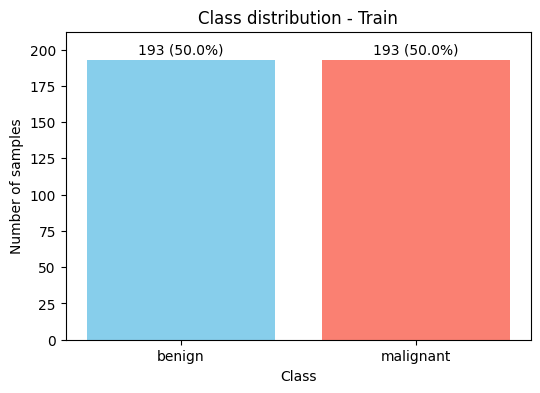

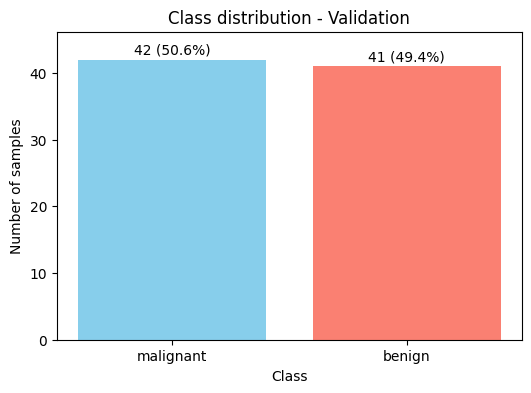

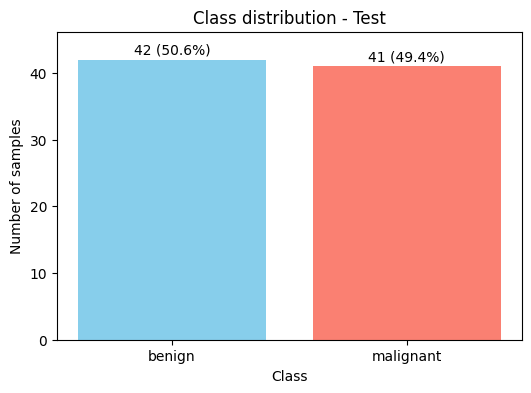

In [ ]:
train_counts = print_class_distribution(train_df, "Train")
val_counts = print_class_distribution(valid_df, "Validation")
test_counts = print_class_distribution(test_df, "Test")

train_count = len(train_df)
val_count = len(valid_df)
test_count = len(test_df)
total_count = train_count + val_count + test_count

plot_class_distribution(train_counts, "Train")
plot_class_distribution(val_counts, "Validation")
plot_class_distribution(test_counts, "Test")

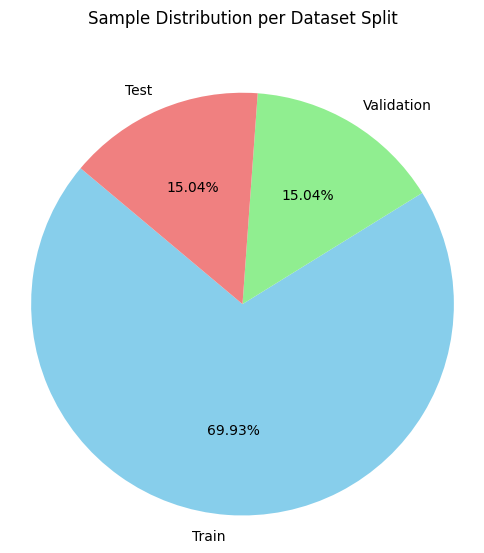


Total number of samples per split:
Train: 386
Validation: 83
Test: 83


In [ ]:
split_labels = ['Train', 'Validation', 'Test']
split_counts = [train_count, val_count, test_count]

plt.figure(figsize=(6, 6))
plt.pie(
    split_counts,
    labels=split_labels,
    autopct='%1.2f%%',
    colors=['skyblue', 'lightgreen', 'lightcoral'],
    startangle=140
)
plt.title('Sample Distribution per Dataset Split\n\n')
plt.axis('equal')
plt.show()

print("\nTotal number of samples per split:")
print(f"Train: {train_count}")
print(f"Validation: {val_count}")
print(f"Test: {test_count}")

# Saving results:

In [87]:
train_df.to_csv('../datasets/sd-198/train_metadata.csv', index=False, encoding='utf-8')
valid_df.to_csv('../datasets/sd-198/validation_metadata.csv', index=False, encoding='utf-8')
test_df.to_csv('../datasets/sd-198/test_metadata.csv', index=False, encoding='utf-8')